In [12]:
from pathlib import Path
import os
import ast
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint

import csv
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.sweep.config import SWEEP_RESULT_FIELDNAMES


In [2]:
BASE_RESULTS_PATH = Path("~/Projects/groundwater/results/fno_simple_henry_sweep").expanduser()
DATASET_NAME = "grid_scenarios_20x40"

results_path = BASE_RESULTS_PATH / DATASET_NAME
pprint([p.name for p in results_path.iterdir()])

['model_weights', 'figures', 'predictions', 'sweep_results.csv']


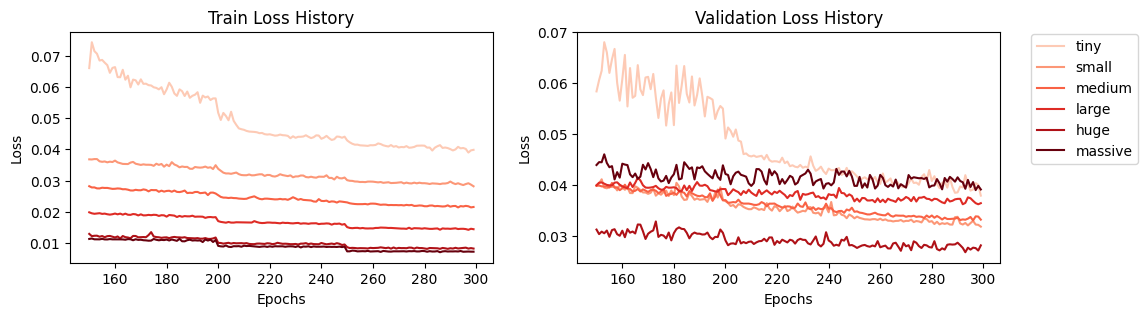

In [45]:
loss_history_dir = results_path / "figures"
loss_history_files = list(d.name for d in (loss_history_dir).iterdir())

fig, ax = plt.subplots(1, 2, figsize=(12, 3))

start_epoch = 150
end_epoch = 300

size_order = ["tiny", "small", "medium", "large", "huge", "massive"]
sorted_loss_history_files = sorted(loss_history_files, key=lambda f: size_order.index(json.load(open(loss_history_dir / f, "r"))['model_size_label']))

# Sequential Reds color map for plotting
colors = plt.cm.Reds(np.linspace(0.2, 1, len(sorted_loss_history_files)))

for f in sorted_loss_history_files:
    loss_history = json.load(open(loss_history_dir / f, "r"))
    index = size_order.index(loss_history['model_size_label'])
    ax[0].plot(np.arange(start_epoch, end_epoch), loss_history["train_loss_history"][start_epoch:end_epoch], label=f"{loss_history['model_size_label']}", color=colors[index])
    ax[1].plot(np.arange(start_epoch, end_epoch), loss_history["val_loss_history"][start_epoch:end_epoch], label=f"{loss_history['model_size_label']}", color=colors[index])


ax[0].set_title("Train Loss History")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[1].set_title("Validation Loss History")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

plt.legend(loc='upper center', bbox_to_anchor=(1.2, 1.02), )


In [47]:
results_csv_path = results_path / "sweep_results.csv"
summary_results = pd.read_csv(results_csv_path)

summary_results = summary_results.sort_values(by=["scenario_name", "total_params", "run_timestamp"],
                                              ascending=True)

summary_results = summary_results.drop_duplicates(subset=["scenario_name", "total_params"], keep="last")

summary_results

,run_timestamp,scenario_name,model_size_label,total_params,rel_l2_error_concentration_train,rel_l2_error_hydraulic_head_train,rel_l2_error_concentration_val,rel_l2_error_hydraulic_head_val
96,2026-09-10T12:55:43,scenario_01,tiny,5718,0.421065,2.516595,0.370569,1.469389
112,2026-09-10T12:58:50,scenario_01,small,26922,0.251798,0.909186,0.249154,0.713957
128,2026-09-10T13:02:44,scenario_01,medium,134770,0.559639,1.082843,0.655989,0.977086
144,2026-09-10T13:07:55,scenario_01,large,1056994,0.504037,1.631704,0.679378,2.414719
160,2026-09-10T13:14:44,scenario_01,huge,4022098,0.149449,0.302656,0.548393,0.917268
...,...,...,...,...,...,...,...,...
127,2026-09-10T12:58:54,scenario_16,small,26922,0.558772,0.892997,0.678882,0.920100
143,2026-09-10T13:02:48,scenario_16,medium,134770,0.595536,0.849621,0.594368,0.930249
159,2026-09-10T13:07:58,scenario_16,large,1056994,0.344729,0.474602,0.638311,0.926784
175,2026-09-10T13:14:48,scenario_16,huge,4022098,0.062107,0.155043,0.405947,0.753314


In [77]:
data_path = Path("~/Projects/groundwater/data/simple_henry_data/grid_scenarios_20x40").expanduser()
scenario_manifest_path = data_path / "scenarios_manifest.json"
scenario_manifest = json.load(open(scenario_manifest_path, "r"))['scenarios']
scenario_manifest_df = pd.DataFrame(scenario_manifest).sort_values(by='scenario_index')
scenario_manifest_df



,scenario_dir,scenario_index,scenario,beta_c,diffc,lag,lag_days,dt,n_total_runs,n_ok_runs,n_skipped_runs,n_failed_runs
0,/Users/akap5486/Projects/groundwater/data/simp...,1,scenario_beta0.010_diffc0.00001,0.01,0.00001,1,0.04,0.04,6,6,0,0
1,/Users/akap5486/Projects/groundwater/data/simp...,2,scenario_beta0.010_diffc0.00010,0.01,0.00010,1,0.04,0.04,6,6,0,0
2,/Users/akap5486/Projects/groundwater/data/simp...,3,scenario_beta0.010_diffc0.01000,0.01,0.01000,1,0.04,0.04,6,6,0,0
3,/Users/akap5486/Projects/groundwater/data/simp...,4,scenario_beta0.010_diffc0.10000,0.01,0.10000,1,0.04,0.04,6,6,0,0
4,/Users/akap5486/Projects/groundwater/data/simp...,5,scenario_beta0.050_diffc0.00001,0.05,0.00001,1,0.04,0.04,6,6,0,0
5,/Users/akap5486/Projects/groundwater/data/simp...,6,scenario_beta0.050_diffc0.00010,0.05,0.00010,1,0.04,0.04,6,6,0,0
6,/Users/akap5486/Projects/groundwater/data/simp...,7,scenario_beta0.050_diffc0.01000,0.05,0.01000,1,0.04,0.04,6,6,0,0
7,/Users/akap5486/Projects/groundwater/data/simp...,8,scenario_beta0.050_diffc0.10000,0.05,0.10000,1,0.04,0.04,6,6,0,0
8,/Users/akap5486/Projects/groundwater/data/simp...,9,scenario_beta0.100_diffc0.00001,0.10,0.00001,1,0.04,0.04,6,6,0,0
9,/Users/akap5486/Projects/groundwater/data/simp...,10,scenario_beta0.100_diffc0.00010,0.10,0.00010,1,0.04,0.04,6,6,0,0


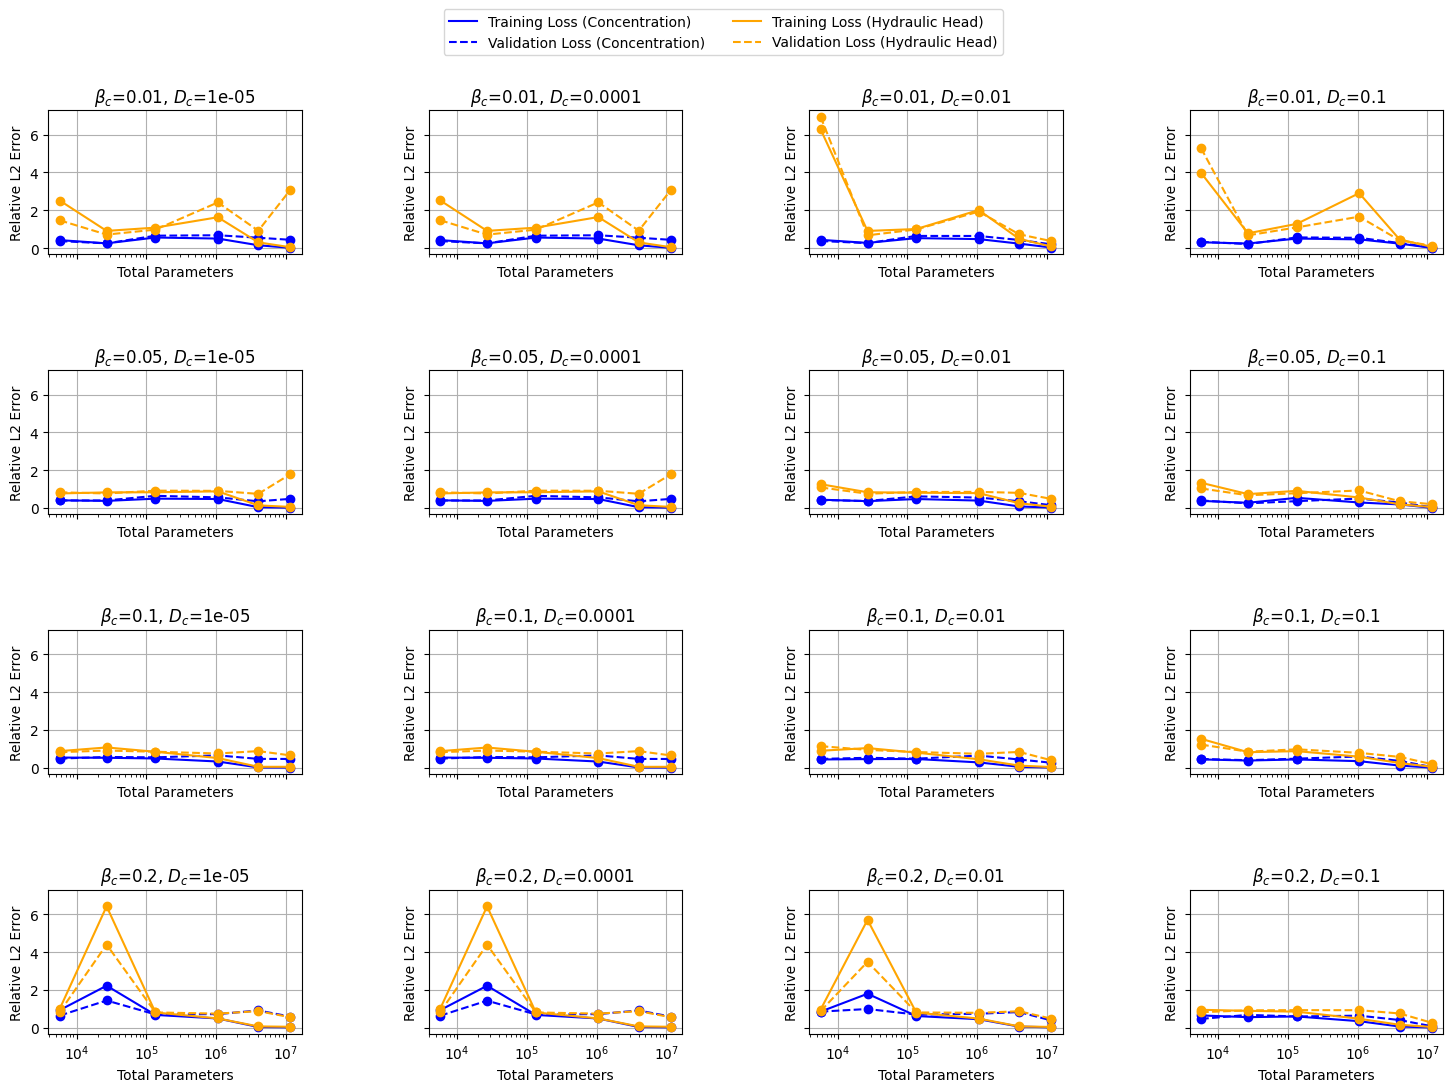

In [79]:
fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex=True, sharey=True)

for i, scenario_name in enumerate(summary_results["scenario_name"].unique()):
    scenario_index = int(scenario_name.split("_")[-1])
    ax = axes[i // 4, i % 4]
    scenario_results = summary_results[summary_results["scenario_name"] == scenario_name]
    ax.plot(scenario_results["total_params"], scenario_results["rel_l2_error_concentration_train"], 
            marker='o', label="Training Loss", color='blue', linestyle='-')
    ax.plot(scenario_results["total_params"], scenario_results["rel_l2_error_concentration_val"], 
            marker='o', label="Validation Loss", color='blue', linestyle='--')

    ax.plot(scenario_results["total_params"], scenario_results["rel_l2_error_hydraulic_head_train"], 
            marker='o', label="Training Loss", color='orange', linestyle='-')
    ax.plot(scenario_results["total_params"], scenario_results["rel_l2_error_hydraulic_head_val"], 
            marker='o', label="Validation Loss", color='orange', linestyle='--')
    ax.set_xlabel("Total Parameters")
    ax.set_ylabel("Relative L2 Error")
    ax.set_xscale('log')
    scenario_details = scenario_manifest_df.loc[scenario_manifest_df['scenario_index'] == scenario_index].iloc[0]
    ax.set_title(f"$\\beta_c$={scenario_details['beta_c']}, $D_c$={scenario_details['diffc']}")

    # ax.set_yscale('log')
    ax.grid(True)

# Set common legend for all subplots
# Create custom legend handles and labels for color and linestyle
handles = [
    plt.Line2D([0], [0], color='blue', linestyle='-', label='Training Loss (Concentration)'),
    plt.Line2D([0], [0], color='blue', linestyle='--', label='Validation Loss (Concentration)'),
    plt.Line2D([0], [0], color='orange', linestyle='-', label='Training Loss (Hydraulic Head)'),
    plt.Line2D([0], [0], color='orange', linestyle='--', label='Validation Loss (Hydraulic Head)')
]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=2)

# vertical spacing
plt.subplots_adjust(hspace=0.8, wspace=0.5)

In [ ]:
results_csv_path = results_path / "scenarios_run_000003_fno_sweep_results.csv"
summary_results = pd.read_csv(results_csv_path)

SELECTED_COLUMNS = ['scenario', 'model_size_label', 'total_params',
                    'val_rollout_l2_channels', 'val_rel_l2_denorm_channels',
                    'train_rollout_l2_channels', 'train_rel_l2_denorm_channels',
                    'val_rollout_channel_names', 'val_rollout_channel_names']

results_summary = summary_results[SELECTED_COLUMNS].sort_values(by=['scenario', 'total_params'])

channel_cols = [
    'val_rollout_l2_channels',
    'val_rel_l2_denorm_channels',
    'train_rollout_l2_channels',
    'train_rel_l2_denorm_channels',
]

# Names corresponding to channel index 0 and 1
channel_names = ['concentration', 'head']  # or ['ch0', 'ch1']

for col in channel_cols:
    # 1. Parse string to list (if not already parsed)
    parsed_series = results_summary[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
    # 2. Assign to two separate columns (e.g., val_rollout_l2_concentration, val_rollout_l2_head)
    base_name = col.replace('_channels', '')
    for idx, ch_name in enumerate(channel_names):
        results_summary[f"{base_name}_{ch_name}"] = parsed_series.apply(lambda x: x[idx])

# (Optional) Drop the original combined list columns:
results_summary.drop(columns=channel_cols, inplace=True)
results_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   scenario                           6 non-null      str    
 1   model_size_label                   6 non-null      str    
 2   total_params                       6 non-null      int64  
 3   val_rollout_channel_names          6 non-null      str    
 4   val_rollout_channel_names          6 non-null      str    
 5   val_rollout_l2_concentration       6 non-null      float64
 6   val_rollout_l2_head                6 non-null      float64
 7   val_rel_l2_denorm_concentration    6 non-null      float64
 8   val_rel_l2_denorm_head             6 non-null      float64
 9   train_rollout_l2_concentration     6 non-null      float64
 10  train_rollout_l2_head              6 non-null      float64
 11  train_rel_l2_denorm_concentration  6 non-null      float64
 12  train_rel

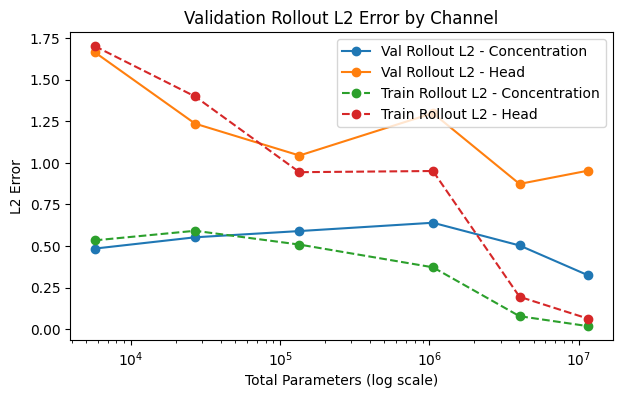

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(results_summary['total_params'], results_summary['val_rollout_l2_concentration'], label='Val Rollout L2 - Concentration', marker='o')
ax.plot(results_summary['total_params'], results_summary['val_rollout_l2_head'], label='Val Rollout L2 - Head', marker='o')
ax.plot(results_summary['total_params'], results_summary['train_rollout_l2_concentration'], label='Train Rollout L2 - Concentration', marker='o', linestyle='--')
ax.plot(results_summary['total_params'], results_summary['train_rollout_l2_head'], label='Train Rollout L2 - Head', marker='o', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('Total Parameters (log scale)')
ax.set_ylabel('L2 Error')
ax.set_title('Validation Rollout L2 Error by Channel')
ax.legend()

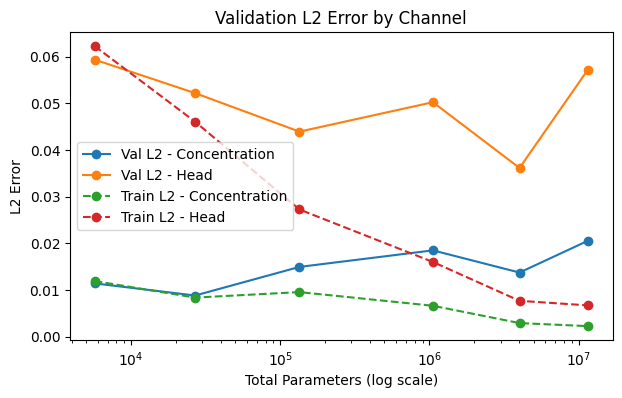

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(results_summary['total_params'], results_summary['val_rel_l2_denorm_concentration'], label='Val L2 - Concentration', marker='o')
ax.plot(results_summary['total_params'], results_summary['val_rel_l2_denorm_head'], label='Val L2 - Head', marker='o')
ax.plot(results_summary['total_params'], results_summary['train_rel_l2_denorm_concentration'], label='Train L2 - Concentration', marker='o', linestyle='--')
ax.plot(results_summary['total_params'], results_summary['train_rel_l2_denorm_head'], label='Train L2 - Head', marker='o', linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('Total Parameters (log scale)')
ax.set_ylabel('L2 Error')
ax.set_title('Validation L2 Error by Channel')
ax.legend()

In [7]:
results_per_scenario_csv_path = results_path / "scenarios_run_000003_fno_sweep_per_scenario_results.csv"

# with open(results_per_scenario_csv_path, "r") as f:
#     rows = list(csv.reader(f))

# old_header = rows[0]
# old_rows = rows[1:113]   # 112 rows from pre-rollout sweep (16 scenarios x 7 models)
# new_rows = rows[113:]    # 128 rows with 28 columns (rollout runs)

# # 1. Save legacy pre-rollout runs to a backup file
# legacy_path = results_per_scenario_csv_path.with_name("scenarios_run_000003_fno_sweep_per_scenario_results_legacy.csv")
# with open(legacy_path, "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(old_header)
#     writer.writerows(old_rows)

# # 2. Overwrite results_per_scenario_csv_path with 28-column header and rollout runs
# with open(results_per_scenario_csv_path, "w", newline="") as f:
#     writer = csv.writer(f)
#     writer.writerow(SWEEP_PER_SCENARIO_RESULT_FIELDNAMES)
#     writer.writerows(new_rows)

# print(f"Successfully backed up {len(old_rows)} legacy rows and saved {len(new_rows)} rollout rows.")

In [9]:
SELECTED_COLUMNS_PER_SCENARIO = ['scenario_name', 'model_size_label',
                                 'val_rollout_l2_channels', 'train_rollout_l2_channels']

results_summary_per_scenario = pd.read_csv(results_per_scenario_csv_path)
results_summary_per_scenario = results_summary_per_scenario[SELECTED_COLUMNS_PER_SCENARIO]
results_summary_per_scenario = results_summary_per_scenario.merge(results_summary[['model_size_label', 'total_params']].drop_duplicates(), 
                                                                  left_on='model_size_label', right_on='model_size_label', how='left')

results_summary_per_scenario = results_summary_per_scenario.sort_values(by=['scenario_name', 'total_params'])

channel_cols = [
    'val_rollout_l2_channels',
    'train_rollout_l2_channels',
]

# Names corresponding to channel index 0 and 1
channel_names = ['concentration', 'head']  # or ['ch0', 'ch1']

for col in channel_cols:
    # 1. Parse string to list (if not already parsed)
    parsed_series = results_summary_per_scenario[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )
    
    # 2. Assign to two separate columns (e.g., val_rollout_l2_concentration, val_rollout_l2_head)
    base_name = col.replace('_channels', '')
    for idx, ch_name in enumerate(channel_names):
        results_summary_per_scenario[f"{base_name}_{ch_name}"] = parsed_series.apply(lambda x: x[idx])

# (Optional) Drop the original combined list columns:
results_summary_per_scenario.drop(columns=channel_cols, inplace=True)
results_summary_per_scenario.info()


<class 'pandas.DataFrame'>
Index: 96 entries, 0 to 95
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   scenario_name                   96 non-null     str    
 1   model_size_label                96 non-null     str    
 2   total_params                    96 non-null     int64  
 3   val_rollout_l2_concentration    96 non-null     float64
 4   val_rollout_l2_head             96 non-null     float64
 5   train_rollout_l2_concentration  96 non-null     float64
 6   train_rollout_l2_head           96 non-null     float64
dtypes: float64(4), int64(1), str(2)
memory usage: 6.0 KB


In [10]:
results_summary_per_scenario.scenario_name.unique()

<StringArray>
['scenario_01', 'scenario_02', 'scenario_03', 'scenario_04', 'scenario_05',
 'scenario_06', 'scenario_07', 'scenario_08', 'scenario_09', 'scenario_10',
 'scenario_11', 'scenario_12', 'scenario_13', 'scenario_14', 'scenario_15',
 'scenario_16']
Length: 16, dtype: str

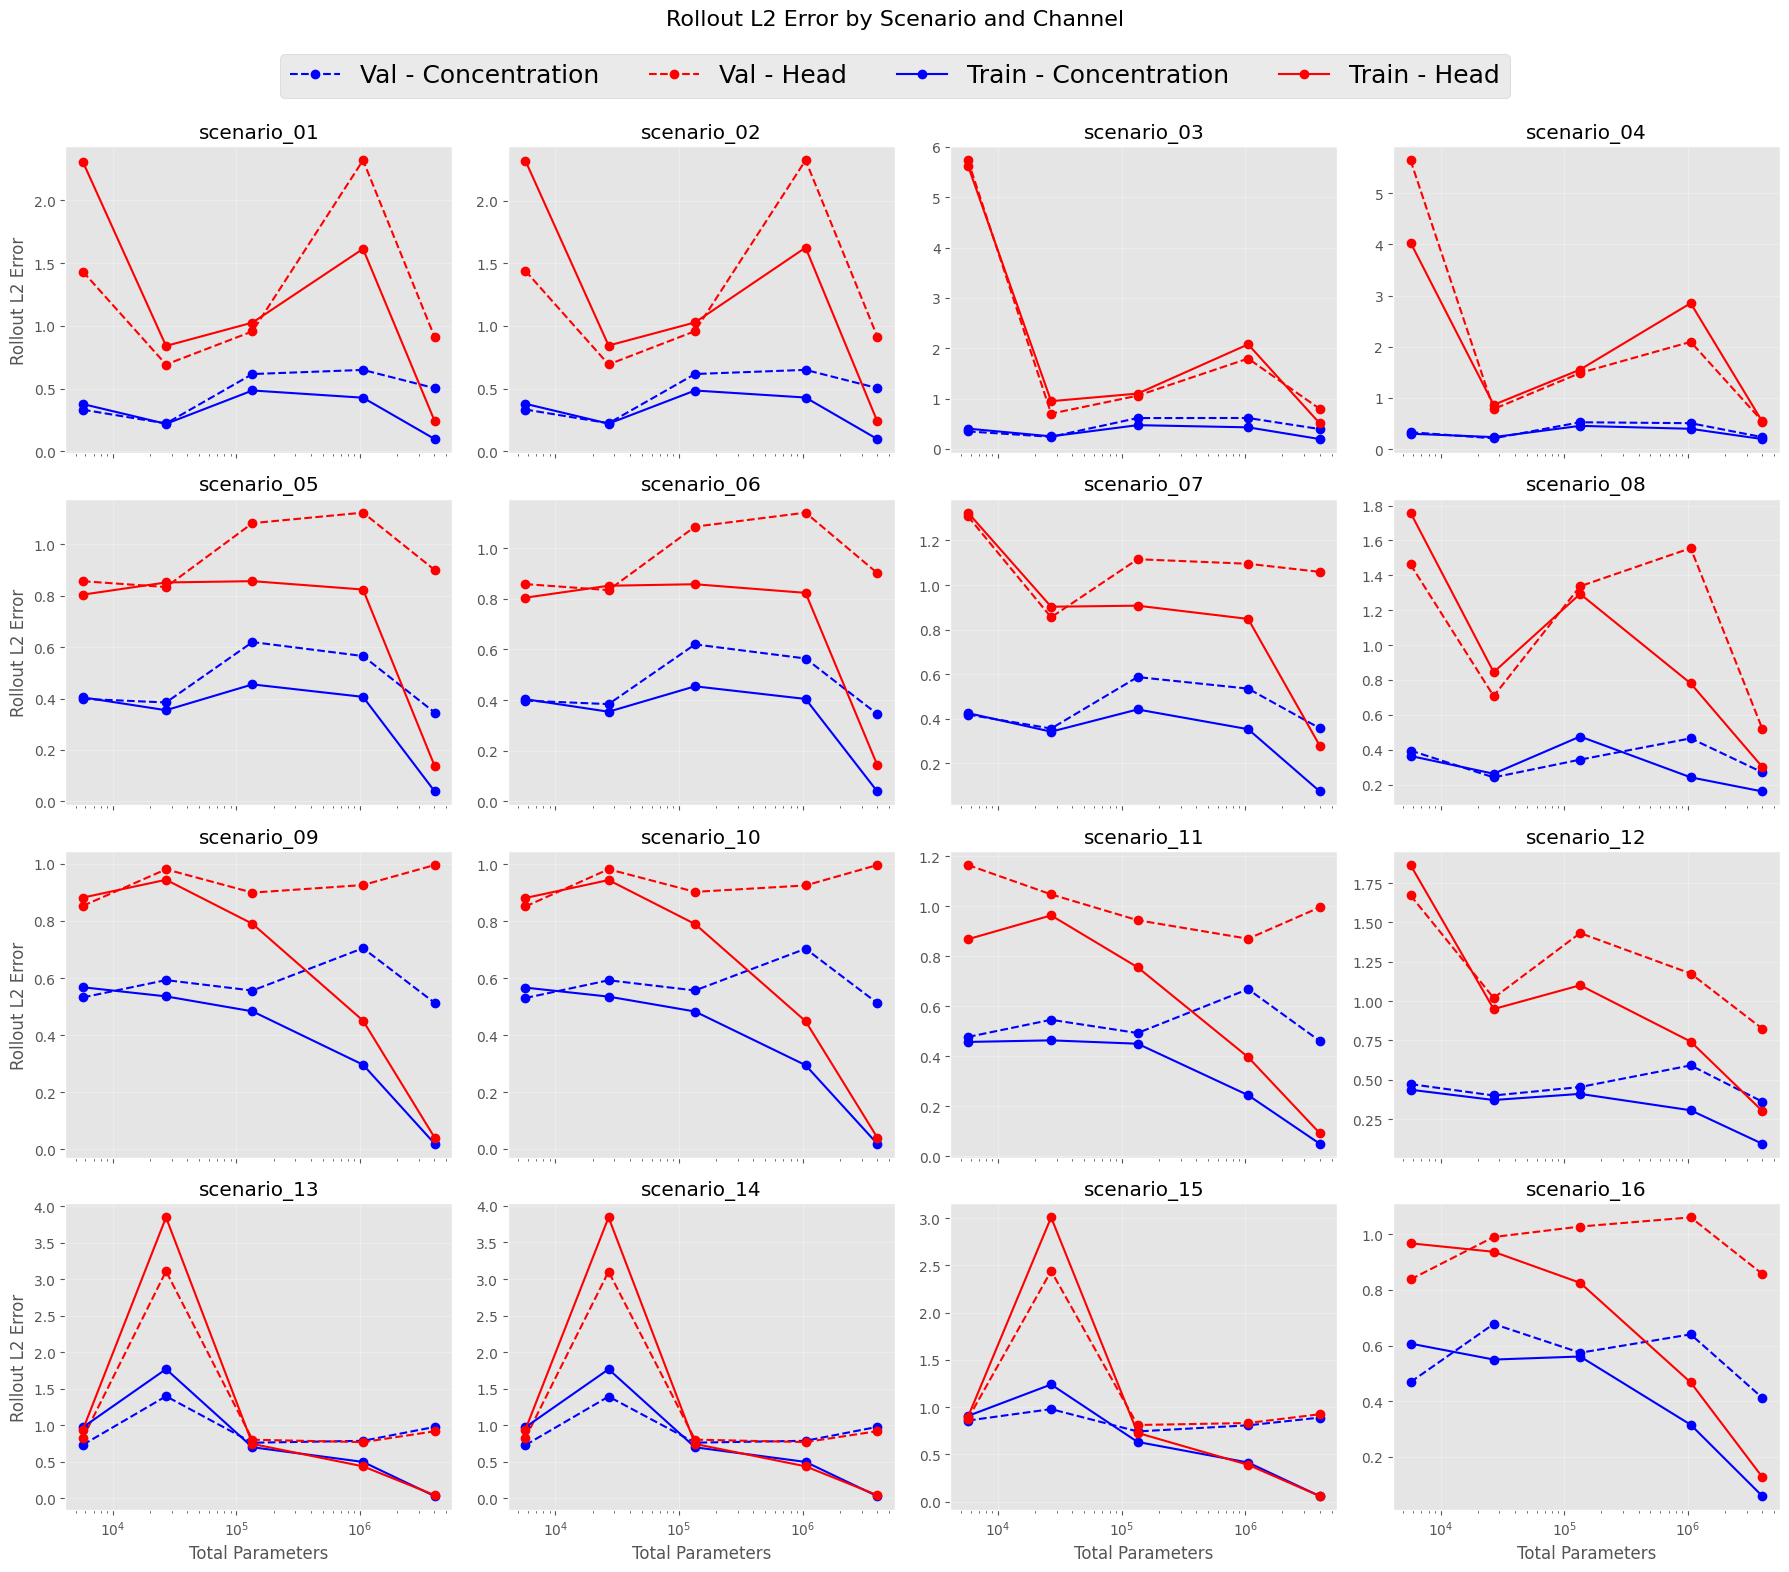

In [15]:
# Create a 4x4 grid of subplots, one for each scenario
plt.style.use('ggplot')


results_summary_per_scenario = results_summary_per_scenario.loc[results_summary_per_scenario['model_size_label'] != 'massive']


scenario_groups = list(
    results_summary_per_scenario
    .sort_values(['scenario_name', 'total_params'])
    .groupby('scenario_name')
)

fig, axes = plt.subplots(
    4, 4,
    figsize=(18, 16),
    sharex=True,
    # sharey=True,
)

axes = axes.flatten()

for ax, (scenario_name, scenario_df) in zip(axes, scenario_groups):
    ax.plot(
        scenario_df['total_params'],
        scenario_df['val_rollout_l2_concentration'],
        marker='o',
        label='Val - Concentration',
        linestyle='--',
        color='blue'
    )
    ax.plot(
        scenario_df['total_params'],
        scenario_df['val_rollout_l2_head'],
        marker='o',
        label='Val - Head',
        linestyle='--',
        color='red'
    )
    ax.plot(
        scenario_df['total_params'],
        scenario_df['train_rollout_l2_concentration'],
        marker='o',
        linestyle='-',
        label='Train - Concentration',
        color='blue'
    )
    ax.plot(
        scenario_df['total_params'],
        scenario_df['train_rollout_l2_head'],
        marker='o',
        linestyle='-',
        label='Train - Head',
        color='red'
    )

    ax.set_xscale('log')
    ax.set_title(scenario_name)
    ax.grid(True, alpha=0.3)

for ax in axes[12:]:
    ax.set_xlabel('Total Parameters')

for ax in axes[::4]:
    ax.set_ylabel('Rollout L2 Error')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=18, bbox_to_anchor=(0.5, 0.96))

fig.suptitle('Rollout L2 Error by Scenario and Channel', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94])


In [13]:
# import re
# import matplotlib.pyplot as plt
# from collections import defaultdict

# # Initialize data structure to hold epoch metrics per model configuration
# runs = defaultdict(lambda: {'epochs': [], 'train_loss': [], 'val_loss': []})

# # Regular expression to extract epoch, hidden channels, and losses
# pattern = re.compile(r"Epoch\s+(\d+)/\d+\s+-\s+hidden_channels:\s+(\d+),\s+train_l2:\s+([0-9.]+),\s+val_l2:\s+([0-9.]+)")

# # Read and parse the log file
# with open(str(Path("~/Desktop/sweep_hidden_dims.txt").expanduser()), "r") as f:
#     for line in f:
#         match = pattern.search(line)
#         if match:
#             epoch = int(match.group(1))
#             hc = int(match.group(2))
#             train_loss = float(match.group(3))
#             val_loss = float(match.group(4))
            
#             runs[hc]['epochs'].append(epoch)
#             runs[hc]['train_loss'].append(train_loss)
#             runs[hc]['val_loss'].append(val_loss)

# # Generate the side-by-side plots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# # Map hidden channels to their dataset labels for the legend
# labels = {8: 'Tiny (8)', 16: 'Small (16)', 24: 'Medium (24)', 
#           32: 'Base (32)', 40: 'Large (40)', 48: 'Huge (48)', 56: 'Massive (56)'}

# for hc, data in sorted(runs.items()):
#     label = labels.get(hc, f"HC: {hc}")
#     ax1.plot(data['epochs'], data['train_loss'], label=label, linewidth=1.5)
#     ax2.plot(data['epochs'], data['val_loss'], label=label, linewidth=1.5)

# # Formatting Training Plot
# ax1.set_title('Training Loss (train_l2) vs Epoch')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('L2 Loss (Log Scale)')
# ax1.set_yscale('log')
# ax1.grid(True, which="both", ls="--", alpha=0.5)
# ax1.legend()

# # Formatting Validation Plot
# ax2.set_title('Validation Loss (val_l2) vs Epoch')
# ax2.set_xlabel('Epoch')
# ax2.set_yscale('log')
# ax2.grid(True, which="both", ls="--", alpha=0.5)
# ax2.legend()

# plt.suptitle('FNO Sweep: Train and Validation Loss vs Epoch', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.savefig("loss_vs_epoch_sweep.png", dpi=300)
# plt.show()


In [127]:
single_step_npz = results_path / "validation_final_step_artifacts/scenarios/run_000003/per_scenario/scenario_01_massive_val_all_steps.npz"
rollout_npz = results_path / "validation_final_step_artifacts/scenarios/run_000003/rollout/scenarios_run_000003_massive_val_rollout.npz"

single_step_data = np.load(single_step_npz, allow_pickle=True)
rollout_data = np.load(rollout_npz, allow_pickle=True)

pprint(single_step_data.files)
pprint(rollout_data.files)

['predictions_all',
 'ground_truth_all',
 'abs_error_all',
 'prediction',
 'ground_truth',
 'abs_error']
['rollout_preds', 'ground_truth', 'abs_error']


In [125]:
single_step_preds = single_step_data['predictions_all']
single_step_targets = single_step_data['ground_truth_all']

rollout_preds = rollout_data['rollout_preds']
rollout_targets = rollout_data['ground_truth']

print(single_step_preds.shape, single_step_targets.shape)
print(rollout_preds.shape, rollout_targets.shape)

(245, 2, 20, 40) (245, 2, 20, 40)
(49, 2, 20, 40) (49, 2, 20, 40)


IndexError: index 50 is out of bounds for axis 0 with size 49

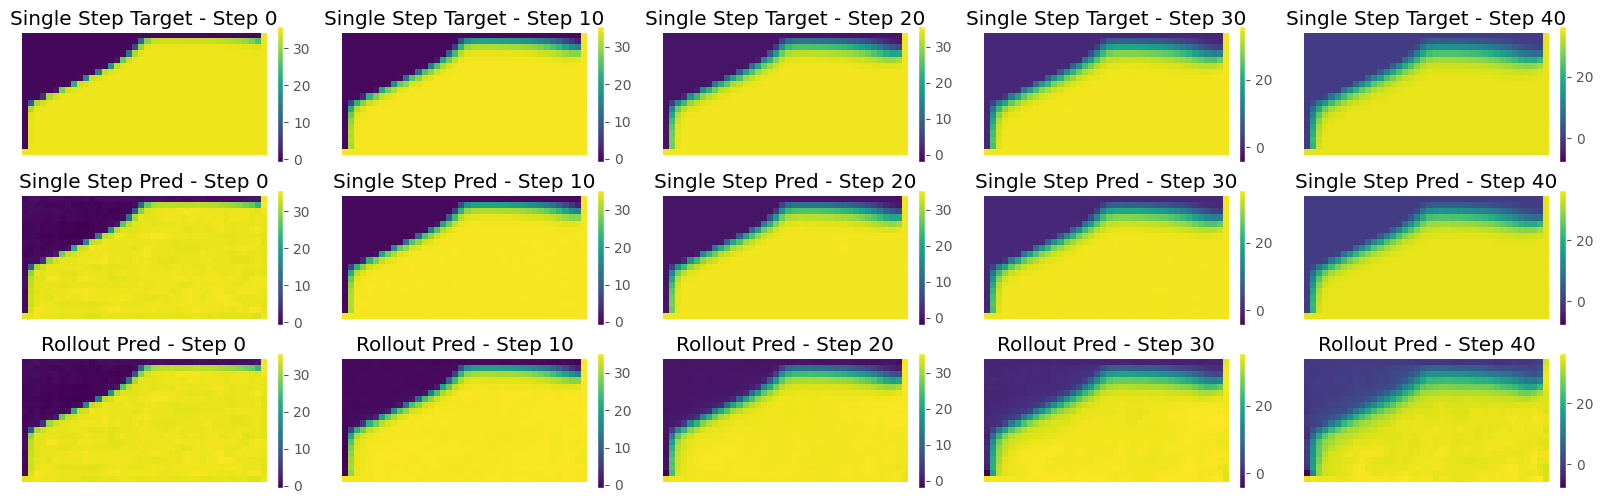

In [126]:
n_steps = single_step_preds.shape[0]

fig, axes = plt.subplots(3, 5, figsize=(20, 6))


for step in range(0, n_steps+1, 10):

    ax_idx = step // 10

    vmin = min(single_step_preds[step, 0].min(), single_step_targets[step, 0].min(),
               rollout_preds[step, 0].min(), rollout_targets[step, 0].min())
    vmax = max(single_step_preds[step, 0].max(), single_step_targets[step, 0].max(),
               rollout_preds[step, 0].max(), rollout_targets[step, 0].max())

    im = axes[0, ax_idx].imshow(single_step_targets[step, 0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, ax_idx].set_title(f'Single Step Target - Step {step}')
    axes[0, ax_idx].axis('off')
    plt.colorbar(im, ax=axes[0, ax_idx], fraction=0.046, pad=0.04)

    im = axes[1, ax_idx].imshow(single_step_preds[step, 0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, ax_idx].set_title(f'Single Step Pred - Step {step}')
    axes[1, ax_idx].axis('off')
    plt.colorbar(im, ax=axes[1, ax_idx], fraction=0.046, pad=0.04)

    im = axes[2, ax_idx].imshow(rollout_preds[step, 0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[2, ax_idx].set_title(f'Rollout Pred - Step {step}')
    axes[2, ax_idx].axis('off')
    plt.colorbar(im, ax=axes[2, ax_idx], fraction=0.046, pad=0.04)



